<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Hands-on Lab : Web Scraping**


Estimated time needed: **30 to 45** minutes


## Objectives


In this lab you will perform the following:


* Extract information from a given web site 
* Write the scraped data into a csv file.


## Extract information from the given web site
You will extract the data from the below web site: <br> 


In [1]:
#this url contains the data you need to scrape
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/labs/datasets/Programming_Languages.html"

The data you need to scrape is the **name of the programming language** and **average annual salary**.<br> It is a good idea to open the url in your web broswer and study the contents of the web page before you start to scrape.


Import the required libraries


In [2]:
from bs4 import BeautifulSoup
import requests

Download the webpage at the url


In [3]:
data  = requests.get(url).text

Create a soup object


In [4]:
soup = BeautifulSoup(data,"html.parser")

Scrape the `Language name` and `annual average salary`.


In [5]:
table = soup.find('table')

languages = []

for row in table.find_all('tr'):
    cols = row.find_all('td')
    
    language = cols[1].getText()
    average_salary = cols[3].getText()
    
    languages.append({"Language": language, "Average Salary": average_salary})
    print(f"{language} ---> {average_salary}")

Language ---> Average Annual Salary
Python ---> $114,383
Java ---> $101,013
R ---> $92,037
Javascript ---> $110,981
Swift ---> $130,801
C++ ---> $113,865
C# ---> $88,726
PHP ---> $84,727
SQL ---> $84,793
Go ---> $94,082


Save the scrapped data into a file named *popular-languages.csv*


In [6]:
import os
import pandas as pd

output_dir = "outputs"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

df = pd.DataFrame(languages)

# The first row contains the column names, so we can remove it
df = df[1:] 

file_path = os.path.join(output_dir, "popular-languages.csv")
df.to_csv(file_path, index=False)

print(f"Data saved to: {file_path}")

Data saved to: outputs\popular-languages.csv


<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
C:\Users\Hp\AppData\Local\Temp\ipykernel_21912\249209849.py:9: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


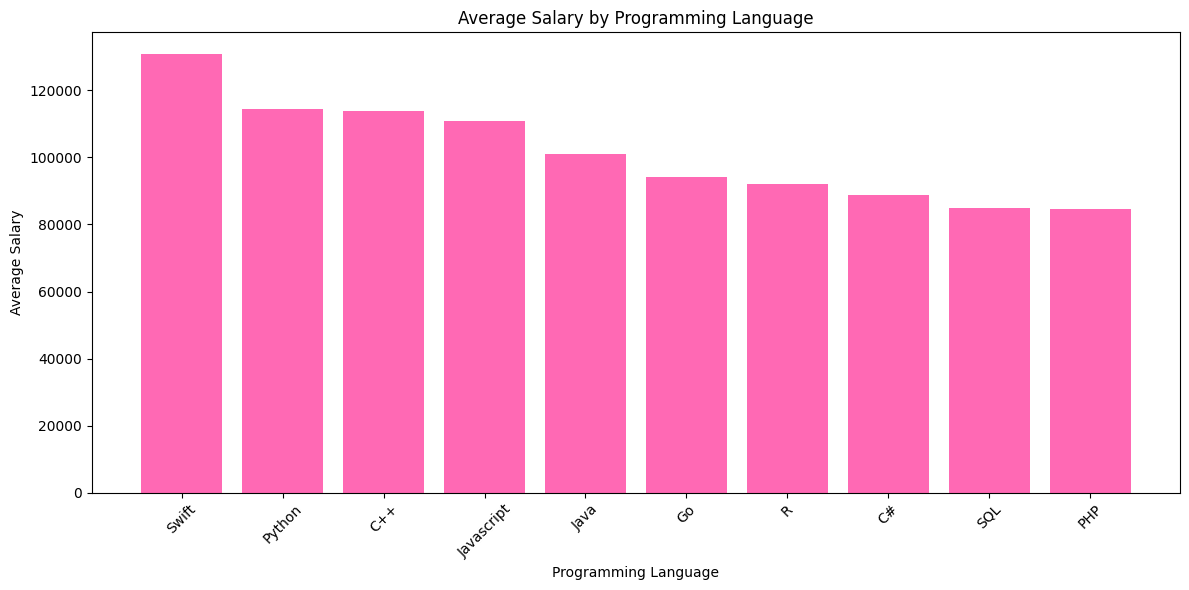

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./outputs/popular-languages.csv")

# Convert salary column to numeric
df["Average Salary"] = (
    df["Average Salary"]
        .replace('[\$,]', '', regex=True)
        .astype(float)
)

# Sort descending
df_sorted = df.sort_values(by="Average Salary", ascending=False)

plt.figure(figsize=(12,6))
plt.bar(df_sorted["Language"], df_sorted["Average Salary"], color="#FF69B4")

plt.title("Average Salary by Programming Language")
plt.xlabel("Programming Language")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Authors


Ramesh Sannareddy


### Other Contributors


Rav Ahuja


## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2020-10-17  | 0.1  | Ramesh Sannareddy  |  Created initial version of the lab |


 Copyright &copy; 2020 IBM Corporation. This notebook and its source code are released under the terms of the [MIT License](https://cognitiveclass.ai/mit-license/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDA0321ENSkillsNetwork928-2022-01-01).
